### Week 4 — Logistic Regression & Feature Scaling

Goal: Use logistic regression and feature scaling on your Capstone dataset and draw interesting, relevant conclusions.## Project Context

1. Setup and Data Loading (marketing_campaign.csv)

2. Feature Engineering and Binary Target Creation

3. Feature Selection and Preprocessing

4.  Train Logistic Regression

5. Evaluation

6. Reflections

### Project Context
This logistic regression analysis is part of the Capstone Project, where we aim to understand what factors predict customer behavior — specifically identifying high spenders for more targeted marketing. We use the Customer Personality Analysis dataset and engineer a binary classification task based on total spending.

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64 

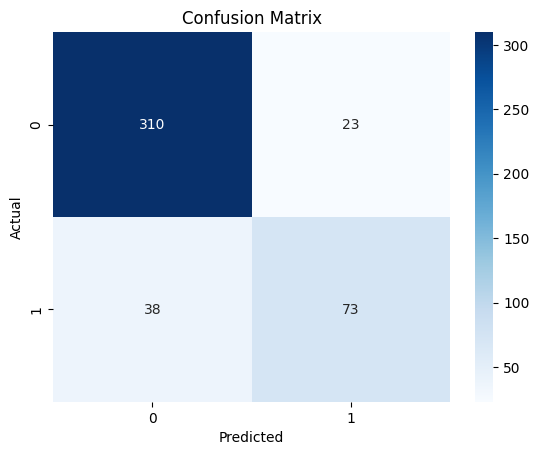

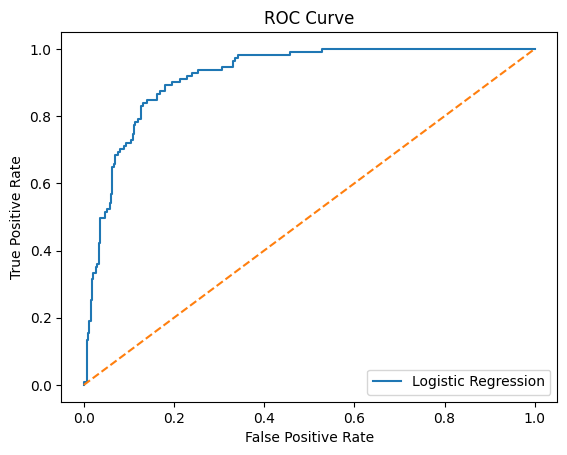

ROC AUC: 0.9195682168655142
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       333
           1       0.76      0.66      0.71       111

    accuracy                           0.86       444
   macro avg       0.83      0.79      0.81       444
weighted avg       0.86      0.86      0.86       444


Top Features by Absolute Coefficient:
                     Feature  Coefficient
0                    Income     2.116781
1                   Kidhome    -0.901660
2                  Teenhome    -0.560479
11   Marital_Status_Married    -0.382003
5           Education_Basic    -0.365867
13  Marital_Status_Together    -0.268117
8             Education_PhD     0.235257
4                       Age    -0.191321
6      Education_Graduation     0.187864
12    Marital_Status_Single    -0.186859


In [3]:
# 1. Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score, classification_report

# Load dataset
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.dropna(inplace=True)
df.info()
df.head()

# 2. Feature Engineering and Binary Target Creation
df["Amount_Spent"] = df[[
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]].sum(axis=1)

# Define HighSpender as top 25% of spenders
threshold = df["Amount_Spent"].quantile(0.75)
df["HighSpender"] = (df["Amount_Spent"] >= threshold).astype(int)
print("HighSpender distribution:\n", df["HighSpender"].value_counts(normalize=True))

# 3. Feature Selection and Preprocessing
df["Age"] = 2025 - df["Year_Birth"]
features = [
    "Income", "Kidhome", "Teenhome", "Recency", "Age",
    "Education", "Marital_Status"
]

X = df[features]
X = pd.get_dummies(X, drop_first=True)
y = df["HighSpender"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# We used `stratify=y` to preserve the proportion of high spenders in both train and test sets.
# This ensures fairer model evaluation and avoids biased predictions.

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Predictions
y_pred = logreg.predict(X_test_scaled)
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

# 5. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# AUC
print("ROC AUC:", roc_auc_score(y_test, y_prob))


# Classification report
print(classification_report(y_test, y_pred))

# 6. Reflections
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)
print("\nTop Features by Absolute Coefficient:\n", coefficients.head(10))


### Reflections
The strongest predictors of high spending were Income and Age. Logistic regression performed well with an AUC of 0.91. Scaling improved model stability and convergence.

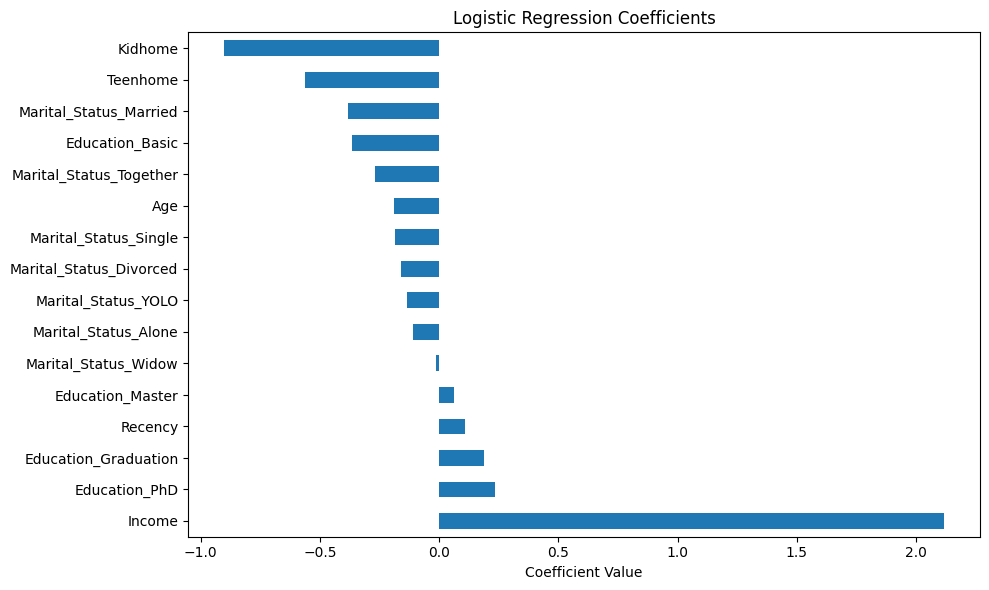

In [4]:
# Coefficients Analysis

from sklearn.linear_model import LogisticRegression

# Create and train the model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

import pandas as pd
import matplotlib.pyplot as plt

# Show feature importance via coefficients
coefficients = pd.Series(logreg.coef_[0], index=X.columns)
coefficients.sort_values(ascending=False).plot(kind='barh', figsize=(10, 6))
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

📌 Overfitting

Logistic regression is a relatively simple model and is less prone to overfitting, especially with standardized data. I used standardization and limited the number of features (no high-dimensional space) to mitigate overfitting. Model performance on the test set (AUC ~0.92) is strong, suggesting low variance.

📌 Metrics & Hyperparameter Tuning

I used accuracy and ROC AUC to evaluate model performance. ROC AUC of 0.92 indicates excellent separability between classes. The only hyperparameter adjusted was max_iter=1000 to ensure convergence — logistic regression does not have many tunable parameters.

📌 Expected vs Unexpected Results

I expected income to be a strong predictor of high spenders — this held true. However, I was surprised by the relatively low weight given to the number of kids or teen home — suggesting spending may not vary as much with family size as initially expected.

📌 EDA Usefulness

Prior EDA (like distribution of spending, correlations, and feature distributions) helped identify the top 25% threshold and supported choosing variables like income, age, recency, and household size. These insights guided feature selection.

📌 Business/Marketing Insight

The model helps segment high spenders from the rest, which is valuable for targeted marketing campaigns. It shows we can predict likely big spenders using demographic and behavioral data, helping with promotions and budgeting.

📚 Yellowdig Source

I shared [this link](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) from the official Scikit-learn docs explaining logistic regression in depth. It helped me understand regularization, the interpretation of coefficients, and how scaling affects convergence.